# Notebook 4 — Baseline Models

## Why this notebook exists

Before Genetic Algorithm, PSO, or TabNet, we need a **simple reference**.
Baseline models answer:

> "How well can we predict churn with ordinary, easy-to-explain algorithms?"

We train two models:

1. **Logistic Regression** — a linear classifier
2. **Random Forest** — many small decision trees voting together

The stronger one (by F1, then PR-AUC) becomes the **fitness model** inside
GA and PSO in notebooks 5 and 6.

| | |
|---|---|
| **Input** | `data/clean/X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv` |
| **Output** | metrics JSON, confusion-matrix / metric charts, saved model files |
| **Why it is needed** | Gives a score to beat, and a fast model for feature-selection fitness. |

## Metrics in plain English

Because only ~17% of customers churn, **accuracy alone is misleading**.

| Metric | Meaning |
|---|---|
| **Accuracy** | Overall fraction correct (secondary check only) |
| **Precision** | Of customers we flagged as churn, how many truly left? |
| **Recall** | Of customers who truly left, how many did we catch? |
| **F1-score** | Balance of precision and recall |
| **ROC-AUC** | Ranking quality across thresholds |
| **PR-AUC** | Ranking quality with focus on the rare churn class |

We care most about **Recall**, **F1**, and **PR-AUC**.

In [1]:
import os
import json

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

RANDOM_SEED = 42
CLEAN_FOLDER = "../data/clean"
FIGURE_FOLDER = "../figures"
MODEL_FOLDER = "../models"

os.makedirs(FIGURE_FOLDER, exist_ok=True)
os.makedirs(MODEL_FOLDER, exist_ok=True)

X_train = pd.read_csv(CLEAN_FOLDER + "/X_train.csv")
X_test = pd.read_csv(CLEAN_FOLDER + "/X_test.csv")
y_train = pd.read_csv(CLEAN_FOLDER + "/y_train.csv")["Churn"]
y_test = pd.read_csv(CLEAN_FOLDER + "/y_test.csv")["Churn"]

print("Train shape:", X_train.shape, "| churn rate:", round(y_train.mean(), 4))
print("Test shape :", X_test.shape, "| churn rate:", round(y_test.mean(), 4))

Train shape: (4504, 33) | churn rate: 0.1683
Test shape : (1126, 33) | churn rate: 0.1687


## Step 1 — A small evaluate function

This function:

1. Fits the model on train data
2. Predicts the **probability** of churn on test data
3. Turns probability into a 0/1 label using threshold 0.5
4. Computes the metrics above
5. Builds a confusion matrix

`class_weight="balanced"` tells both models to pay more attention to the
rarer churn class.

In [2]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train one model and return metrics, confusion matrix, probabilities."""
    model.fit(X_tr, y_tr)

    # Column 1 = probability of class "churn" (1)
    probabilities = model.predict_proba(X_te)[:, 1]

    predictions = []
    for p in probabilities:
        if p >= 0.5:
            predictions.append(1)
        else:
            predictions.append(0)

    metrics = {
        "model": name,
        "accuracy": float(accuracy_score(y_te, predictions)),
        "precision": float(precision_score(y_te, predictions, zero_division=0)),
        "recall": float(recall_score(y_te, predictions, zero_division=0)),
        "f1": float(f1_score(y_te, predictions, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_te, probabilities)),
        "pr_auc": float(average_precision_score(y_te, probabilities)),
    }
    cm = confusion_matrix(y_te, predictions)
    return metrics, cm, probabilities, predictions


logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_SEED,
)

forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

print("Models created. Ready to train.")

Models created. Ready to train.


### What the main parameters mean

**Logistic Regression**

- `max_iter=1000` — allow enough steps for the solver to finish
- `class_weight="balanced"` — up-weight the rare churn class

**Random Forest**

- `n_estimators=100` — number of trees
- `max_depth=8` — keep trees not too deep (less overfitting)
- `min_samples_leaf=5` — each leaf needs at least 5 samples
- `class_weight="balanced"` — same imbalance handling
- `n_jobs=-1` — use all CPU cores to train faster

In [3]:
all_metrics = []
results = {}

model_list = [
    ("LogisticRegression", logistic_model),
    ("RandomForest", forest_model),
]

for name, model in model_list:
    metrics, cm, probabilities, predictions = evaluate_model(
        name, model, X_train, y_train, X_test, y_test
    )
    all_metrics.append(metrics)
    results[name] = {
        "cm": cm,
        "probabilities": probabilities,
        "predictions": predictions,
        "model": model,
    }
    print()
    print("===", name, "===")
    for key in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]:
        print(key, ":", round(metrics[key], 4))

metrics_table = pd.DataFrame(all_metrics)
metrics_table.to_json(CLEAN_FOLDER + "/baseline_metrics.json", orient="records", indent=2)
metrics_table


=== LogisticRegression ===
accuracy : 0.7886
precision : 0.4351
recall : 0.8474
f1 : 0.575
roc_auc : 0.8865
pr_auc : 0.6724



=== RandomForest ===
accuracy : 0.8917
precision : 0.6349
recall : 0.8421
f1 : 0.724
roc_auc : 0.9525
pr_auc : 0.8263


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,LogisticRegression,0.788632,0.435135,0.847368,0.575000,0.886460,0.672383
1,RandomForest,0.891652,0.634921,0.842105,0.723982,0.952547,0.826305


## Step 2 — Confusion matrices

A confusion matrix counts four outcomes:

| | Predicted Stay (0) | Predicted Leave (1) |
|---|---|---|
| **Actually stayed** | True Negative (TN) | False Positive (FP) |
| **Actually left** | False Negative (FN) | True Positive (TP) |

For churn, **False Negatives** are the costly misses.

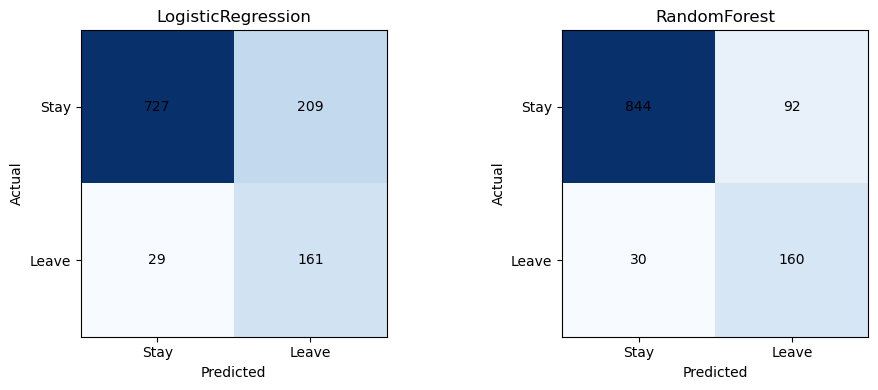

LogisticRegression -> TN: 727 FP: 209 FN: 29 TP: 161
RandomForest -> TN: 844 FP: 92 FN: 30 TP: 160


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
model_names = ["LogisticRegression", "RandomForest"]

for i in range(len(model_names)):
    name = model_names[i]
    cm = results[name]["cm"]
    axes[i].imshow(cm, cmap="Blues")
    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
    axes[i].set_xticks([0, 1])
    axes[i].set_yticks([0, 1])
    axes[i].set_xticklabels(["Stay", "Leave"])
    axes[i].set_yticklabels(["Stay", "Leave"])

    # Write the counts on each cell
    for row in range(2):
        for col in range(2):
            axes[i].text(col, row, str(cm[row, col]), ha="center", va="center", color="black")

fig.tight_layout()
fig.savefig(FIGURE_FOLDER + "/4_confusion_matrices.png", dpi=150)
plt.show()

for name in model_names:
    cm = results[name]["cm"]
    tn = cm[0, 0]
    fp = cm[0, 1]
    fn = cm[1, 0]
    tp = cm[1, 1]
    print(name, "-> TN:", tn, "FP:", fp, "FN:", fn, "TP:", tp)

## Step 3 — Compare metrics side by side

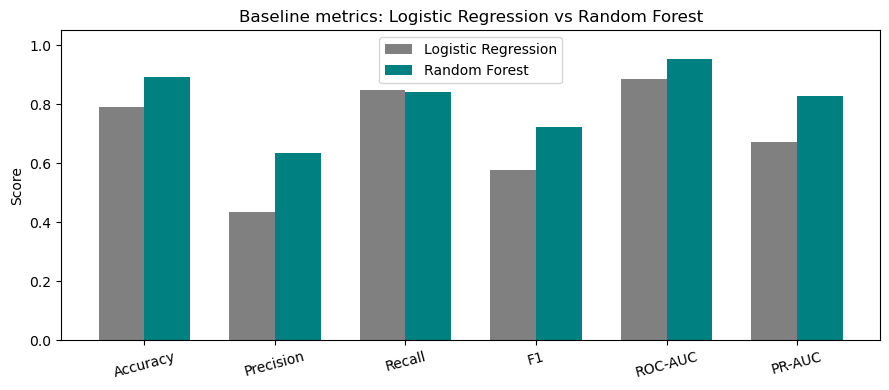

In [5]:
metric_names = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
lr_scores = []
rf_scores = []

for metric_name in metric_names:
    lr_row = metrics_table[metrics_table["model"] == "LogisticRegression"].iloc[0]
    rf_row = metrics_table[metrics_table["model"] == "RandomForest"].iloc[0]
    lr_scores.append(lr_row[metric_name])
    rf_scores.append(rf_row[metric_name])

x_positions = list(range(len(metric_names)))
bar_width = 0.35

plt.figure(figsize=(9, 4))
plt.bar(
    [x - bar_width / 2 for x in x_positions],
    lr_scores,
    width=bar_width,
    label="Logistic Regression",
    color="gray",
)
plt.bar(
    [x + bar_width / 2 for x in x_positions],
    rf_scores,
    width=bar_width,
    label="Random Forest",
    color="teal",
)
plt.xticks(x_positions, ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"], rotation=15)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Baseline metrics: Logistic Regression vs Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_FOLDER + "/4_metric_comparison.png", dpi=150)
plt.show()

## Step 4 — Example predictions (how to read a score)

Each customer gets a probability between 0 and 1:

- closer to **1** → model thinks they will churn
- closer to **0** → model thinks they will stay

At threshold 0.5 we convert that probability into a yes/no decision.
Below we show a few test customers using the Random Forest probabilities.

In [6]:
id_test = pd.read_csv(CLEAN_FOLDER + "/id_test.csv")
rf_probabilities = results["RandomForest"]["probabilities"]
rf_predictions = results["RandomForest"]["predictions"]

example_rows = []
# Show first 8 test customers as a readable sample
for i in range(8):
    customer_id = int(id_test.loc[i, "CustomerID"])
    actual = int(y_test.iloc[i])
    prob = float(rf_probabilities[i])
    pred = int(rf_predictions[i])

    if pred == 1:
        decision = "Predicted LEAVE"
    else:
        decision = "Predicted STAY"

    if actual == pred:
        correct = "correct"
    else:
        correct = "wrong"

    example_rows.append(
        [customer_id, actual, round(prob, 3), decision, correct]
    )

examples = pd.DataFrame(
    example_rows,
    columns=["CustomerID", "ActualChurn", "P(churn)", "Decision", "Result"],
)
print(examples.to_string(index=False))

# Also show the highest-risk and lowest-risk customers in the test set
highest_i = int(rf_probabilities.argmax())
lowest_i = int(rf_probabilities.argmin())

print()
print("Highest risk test customer:")
print("  CustomerID:", int(id_test.loc[highest_i, "CustomerID"]))
print("  P(churn)  :", round(float(rf_probabilities[highest_i]), 3))
print("  Actual    :", int(y_test.iloc[highest_i]))

print()
print("Lowest risk test customer:")
print("  CustomerID:", int(id_test.loc[lowest_i, "CustomerID"]))
print("  P(churn)  :", round(float(rf_probabilities[lowest_i]), 3))
print("  Actual    :", int(y_test.iloc[lowest_i]))

 CustomerID  ActualChurn  P(churn)       Decision  Result
      54007            0     0.097 Predicted STAY correct
      51970            0     0.114 Predicted STAY correct
      54236            0     0.085 Predicted STAY correct
      50106            0     0.166 Predicted STAY correct
      52296            0     0.242 Predicted STAY correct
      54394            0     0.060 Predicted STAY correct
      52952            0     0.187 Predicted STAY correct
      53404            0     0.130 Predicted STAY correct

Highest risk test customer:
  CustomerID: 54023
  P(churn)  : 0.97
  Actual    : 1

Lowest risk test customer:
  CustomerID: 52240
  P(churn)  : 0.027
  Actual    : 0


## Step 5 — Choose the fitness model for GA / PSO

We pick the better baseline using **F1 first**, then **PR-AUC** if tied.
Random Forest is usually preferred because it can capture non-linear patterns
and is still fast enough for repeated cross-validation inside GA and PSO.

In [7]:
import joblib

# Sort by F1 then PR-AUC
ranked = metrics_table.sort_values(["f1", "pr_auc"], ascending=False)
best_row = ranked.iloc[0]
fitness_name = best_row["model"]

print("Selected fitness / reference model:", fitness_name)
print(best_row)

# Save both fitted models
joblib.dump(results["RandomForest"]["model"], MODEL_FOLDER + "/rf_baseline.joblib")
joblib.dump(results["LogisticRegression"]["model"], MODEL_FOLDER + "/lr_baseline.joblib")

choice = {
    "fitness_model": fitness_name,
    "reason": "Higher F1, then higher PR-AUC, on the held-out test set",
    "metrics": all_metrics,
}

with open(CLEAN_FOLDER + "/fitness_model_choice.json", "w", encoding="utf-8") as f:
    json.dump(choice, f, indent=2)

print()
print("Saved models to", MODEL_FOLDER)
print("Saved choice to data/clean/fitness_model_choice.json")

Selected fitness / reference model: RandomForest
model        RandomForest
accuracy         0.891652
precision        0.634921
recall           0.842105
f1               0.723982
roc_auc          0.952547
pr_auc           0.826305
Name: 1, dtype: object

Saved models to ../models
Saved choice to data/clean/fitness_model_choice.json


## Overfitting and underfitting (short viva note)

- **Underfitting** — model is too simple and misses real patterns (train and test both weak).
- **Overfitting** — model memorizes train data and fails on new customers (train strong, test weak).

Our Random Forest uses limited depth (`max_depth=8`) and `min_samples_leaf=5`
to reduce overfitting. The held-out test set is our honesty check.

## Conclusion of notebook 4

- Two baselines are trained and compared.
- Metrics focus on recall / F1 / PR-AUC because churn is rare.
- The stronger model is saved as the fitness model for GA and PSO.

**Files created**

- `data/clean/baseline_metrics.json`
- `data/clean/fitness_model_choice.json`
- `models/lr_baseline.joblib`
- `models/rf_baseline.joblib`
- `figures/4_confusion_matrices.png`
- `figures/4_metric_comparison.png`

**Next:** notebook 5 runs a from-scratch Genetic Algorithm for feature selection.